# Phase 1: China Assets - Cleaning and Preparation

This notebook merges the China EPU (CEPU) and CSI 300 datasets into a unified **monthly** dataframe.

Since CEPU is monthly and CSI 300 is daily, we **aggregate CSI 300 to monthly** frequency (average close, monthly return, monthly volatility) and then merge.

**Input:**
- `data/raw/cepu-china-mainland.csv` → China EPU (monthly, 1949-2025)
- `data/raw/csi300-daily.csv` → CSI 300 Stock Index (daily, 2005-2025)

**Output:**
- `data/processed/cepu_csi300_merged.csv` (monthly frequency)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)

DATA_RAW = Path('../../data/raw')
DATA_PROCESSED = Path('../../data/processed')

## 1. Load CEPU China (Monthly)

In [42]:
# Load CSV generated by notebook 05_cepu_china_mainland_exploration.ipynb
epu = pd.read_csv(DATA_RAW / 'cepu-china-mainland.csv', parse_dates=['Date'])

# Keep only the columns we need
epu = epu[['Date', 'year', 'month', 'EPU']].copy()
epu = epu.rename(columns={'EPU': 'CNEPU'})

print(f"CEPU loaded: {len(epu)} months")
print(f"Date range: {epu['Date'].min()} to {epu['Date'].max()}")
print(f"Missing CNEPU: {epu['CNEPU'].isna().sum()}")
print(f"Zero values: {(epu['CNEPU'] == 0).sum()}")
display(epu.head())

CEPU loaded: 915 months
Date range: 1949-10-01 00:00:00 to 2025-12-01 00:00:00
Missing CNEPU: 2
Zero values: 165


,Date,year,month,CNEPU
0,1949-10-01,1949,10,87.237322
1,1949-11-01,1949,11,40.545627
2,1949-12-01,1949,12,40.074743
3,1950-01-01,1950,1,39.424100
4,1950-02-01,1950,2,200.476594


## 2. Load CSI 300 (Daily)

In [44]:
# Load CSI 300
csi = pd.read_csv(DATA_RAW / 'csi300-daily.csv')

print("Raw columns:", list(csi.columns))
print("Raw shape:", csi.shape)
display(csi.head())

# Parse dates (US format: MM/DD/YYYY)
csi['Date'] = pd.to_datetime(csi['Date'], format='%m/%d/%Y')

# Clean numeric columns (remove commas)
for col in ['Price', 'Open', 'High', 'Low']:
    csi[col] = csi[col].astype(str).str.replace(',', '').astype(float)

# Rename
csi = csi.rename(columns={'Price': 'Close'})
csi = csi[['Date', 'Close', 'Open', 'High', 'Low']]

# Sort ascending
csi = csi.sort_values('Date').reset_index(drop=True)

# Calculate daily log returns
csi['Daily_Return'] = np.log(csi['Close'] / csi['Close'].shift(1))

print(f"\nCSI 300 cleaned: {len(csi)} trading days")
print(f"Date range: {csi['Date'].min()} to {csi['Date'].max()}")
display(csi.head())

Raw columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
Raw shape: (4999, 7)


,Date,Price,Open,High,Low,Vol.,Change %
0,07/29/2025,"4,152.02","4,132.68","4,153.33","4,117.58",230.81K,0.39%
1,07/28/2025,"4,135.82","4,128.20","4,146.12","4,112.97",222.76K,0.21%
2,07/25/2025,"4,127.16","4,145.32","4,150.50","4,117.80",273.60K,-0.53%
3,07/24/2025,"4,149.04","4,116.83","4,152.43","4,111.88",319.63K,0.71%
4,07/23/2025,"4,119.77","4,129.15","4,155.68","4,113.91",300.51K,0.02%



CSI 300 cleaned: 4999 trading days
Date range: 2005-01-04 00:00:00 to 2025-07-29 00:00:00


,Date,Close,Open,High,Low,Daily_Return
0,2005-01-04,982.79,994.77,994.77,980.66,NaN
1,2005-01-05,992.56,981.58,997.32,979.88,0.009892
2,2005-01-06,983.17,993.33,993.79,980.33,-0.009505
3,2005-01-07,983.96,983.05,995.71,979.81,0.000803
4,2005-01-10,993.88,983.76,993.96,979.79,0.010031


## 3. Aggregate CSI 300 to Monthly

For each month we calculate:
- **CSI_Close_Avg**: Average daily close price
- **CSI_Close_Last**: Last trading day close (end of month)
- **CSI_High_Max**: Monthly high
- **CSI_Low_Min**: Monthly low
- **CSI_Return**: Monthly log return (log of last close / previous month's last close)
- **CSI_Vol**: Monthly volatility (std of daily returns within the month)
- **CSI_Trading_Days**: Number of trading days in the month

In [45]:
# Create year-month key
csi['year_month'] = csi['Date'].dt.to_period('M')

# Aggregate to monthly
csi_monthly = csi.groupby('year_month').agg(
    CSI_Close_Avg=('Close', 'mean'),
    CSI_Close_Last=('Close', 'last'),
    CSI_Open_First=('Open', 'first'),
    CSI_High_Max=('High', 'max'),
    CSI_Low_Min=('Low', 'min'),
    CSI_Vol=('Daily_Return', 'std'),
    CSI_Trading_Days=('Close', 'count')
).reset_index()

# Calculate monthly log return from last close prices
csi_monthly = csi_monthly.sort_values('year_month').reset_index(drop=True)
csi_monthly['CSI_Return'] = np.log(csi_monthly['CSI_Close_Last'] / csi_monthly['CSI_Close_Last'].shift(1))

# Convert period back to timestamp (first day of month)
csi_monthly['Date'] = csi_monthly['year_month'].dt.to_timestamp()
csi_monthly['year'] = csi_monthly['Date'].dt.year
csi_monthly['month'] = csi_monthly['Date'].dt.month

# Reorder
csi_monthly = csi_monthly[['Date', 'year', 'month',
                            'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First',
                            'CSI_High_Max', 'CSI_Low_Min',
                            'CSI_Return', 'CSI_Vol', 'CSI_Trading_Days']]

print(f"CSI 300 monthly: {len(csi_monthly)} months")
print(f"Date range: {csi_monthly['Date'].min()} to {csi_monthly['Date'].max()}")
print(f"\nColumns: {list(csi_monthly.columns)}")
print(f"\nMissing values:")
print(csi_monthly.isna().sum())
display(csi_monthly.head(10))

CSI 300 monthly: 247 months
Date range: 2005-01-01 00:00:00 to 2025-07-01 00:00:00

Columns: ['Date', 'year', 'month', 'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First', 'CSI_High_Max', 'CSI_Low_Min', 'CSI_Return', 'CSI_Vol', 'CSI_Trading_Days']

Missing values:
Date                0
year                0
month               0
CSI_Close_Avg       0
CSI_Close_Last      0
CSI_Open_First      0
CSI_High_Max        0
CSI_Low_Min         0
CSI_Return          1
CSI_Vol             0
CSI_Trading_Days    0
dtype: int64


,Date,year,month,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Trading_Days
0,2005-01-01,2005,1,982.409000,954.88,994.77,1006.46,943.44,NaN,0.011958,20
1,2005-02-01,2005,2,1020.900000,1039.99,953.33,1059.48,952.74,0.085381,0.018203,13
2,2005-03-01,2005,3,996.991739,942.20,1039.35,1054.64,928.34,-0.098749,0.010387,23
3,2005-04-01,2005,4,963.126667,932.39,941.43,1008.74,914.83,-0.010466,0.015607,21
4,2005-05-01,2005,5,877.821765,855.95,934.65,937.39,842.10,-0.085539,0.010562,17
5,2005-06-01,2005,6,879.925455,878.69,855.21,925.37,807.78,0.026220,0.023028,22
6,2005-07-01,2005,7,853.140000,888.16,875.93,901.00,818.86,0.010720,0.013625,21
7,2005-08-01,2005,8,927.240435,927.92,887.72,959.34,885.85,0.043794,0.012583,23
8,2005-09-01,2005,9,942.550909,917.39,928.52,971.99,901.38,-0.011413,0.011347,22
9,2005-10-01,2005,10,898.219375,876.28,917.21,926.09,859.69,-0.045847,0.009524,16


## 4. Merge CEPU + CSI 300 (Monthly)

In [46]:
# Merge on year and month (inner join: only months with both datasets)
df = pd.merge(epu[['Date', 'year', 'month', 'CNEPU']],
              csi_monthly.drop(columns=['Date']),
              on=['year', 'month'],
              how='inner')

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print(f"Merged dataset: {len(df)} months")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nColumns: {list(df.columns)}")

Merged dataset: 247 months
Date range: 2005-01-01 00:00:00 to 2025-07-01 00:00:00

Columns: ['Date', 'year', 'month', 'CNEPU', 'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First', 'CSI_High_Max', 'CSI_Low_Min', 'CSI_Return', 'CSI_Vol', 'CSI_Trading_Days']


In [47]:
# Calculate CEPU derived features
df['ΔCNEPU'] = df['CNEPU'].diff()
df['CNEPU_MA12'] = df['CNEPU'].rolling(window=12).mean()
df['CNEPU_Std12'] = df['CNEPU'].rolling(window=12).std()

# Calculate CSI rolling volatility (3-month and 6-month from monthly returns)
df['CSI_Vol3m'] = df['CSI_Return'].rolling(window=3).std()
df['CSI_Vol6m'] = df['CSI_Return'].rolling(window=6).std()

print("Features calculated.")
print(f"Final columns: {list(df.columns)}")
print(f"\nMissing values:")
print(df.isna().sum())

display(df.head(15))

Features calculated.
Final columns: ['Date', 'year', 'month', 'CNEPU', 'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First', 'CSI_High_Max', 'CSI_Low_Min', 'CSI_Return', 'CSI_Vol', 'CSI_Trading_Days', 'ΔCNEPU', 'CNEPU_MA12', 'CNEPU_Std12', 'CSI_Vol3m', 'CSI_Vol6m']

Missing values:
Date                 0
year                 0
month                0
CNEPU                0
CSI_Close_Avg        0
CSI_Close_Last       0
CSI_Open_First       0
CSI_High_Max         0
CSI_Low_Min          0
CSI_Return           1
CSI_Vol              0
CSI_Trading_Days     0
ΔCNEPU               1
CNEPU_MA12          11
CNEPU_Std12         11
CSI_Vol3m            3
CSI_Vol6m            6
dtype: int64


,Date,year,month,CNEPU,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Trading_Days,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Vol3m,CSI_Vol6m
0,2005-01-01,2005,1,48.805328,982.409000,954.88,994.77,1006.46,943.44,NaN,0.011958,20,NaN,NaN,NaN,NaN,NaN
1,2005-02-01,2005,2,39.653267,1020.900000,1039.99,953.33,1059.48,952.74,0.085381,0.018203,13,-9.152061,NaN,NaN,NaN,NaN
2,2005-03-01,2005,3,41.163791,996.991739,942.20,1039.35,1054.64,928.34,-0.098749,0.010387,23,1.510524,NaN,NaN,NaN,NaN
3,2005-04-01,2005,4,79.471275,963.126667,932.39,941.43,1008.74,914.83,-0.010466,0.015607,21,38.307484,NaN,NaN,0.092091,NaN
4,2005-05-01,2005,5,23.716429,877.821765,855.95,934.65,937.39,842.10,-0.085539,0.010562,17,-55.754846,NaN,NaN,0.047617,NaN
5,2005-06-01,2005,6,46.791821,879.925455,878.69,855.21,925.37,807.78,0.026220,0.023028,22,23.075392,NaN,NaN,0.056968,NaN
6,2005-07-01,2005,7,61.578927,853.140000,888.16,875.93,901.00,818.86,0.010720,0.013625,21,14.787106,NaN,NaN,0.060548,0.069851
7,2005-08-01,2005,8,59.427998,927.240435,927.92,887.72,959.34,885.85,0.043794,0.012583,23,-2.150929,NaN,NaN,0.016548,0.059551
8,2005-09-01,2005,9,69.968233,942.550909,917.39,928.52,971.99,901.38,-0.011413,0.011347,22,10.540235,NaN,NaN,0.027783,0.045074
9,2005-10-01,2005,10,52.494494,898.219375,876.28,917.21,926.09,859.69,-0.045847,0.009524,16,-17.473739,NaN,NaN,0.045220,0.048223


## 5. Final Dataset

In [48]:
# Reorder final columns
final_cols = ['Date', 'year', 'month',
              'CNEPU', 'ΔCNEPU', 'CNEPU_MA12', 'CNEPU_Std12',
              'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First',
              'CSI_High_Max', 'CSI_Low_Min',
              'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m',
              'CSI_Trading_Days']

df = df[final_cols]

print(f"Final dataset: {df.shape}")
print(f"Date range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f"Frequency: Monthly")
print(f"\nSummary Statistics:")
display(df.describe())

Final dataset: (247, 17)
Date range: 2005-01 to 2025-07
Frequency: Monthly

Summary Statistics:


,Date,year,month,CNEPU,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Trading_Days
count,247,247.000000,247.00000,247.000000,246.000000,236.000000,236.000000,247.000000,247.000000,247.000000,247.000000,247.000000,246.000000,247.000000,244.000000,241.000000,247.000000
mean,2015-04-01 17:46:52.955465472,2014.797571,6.42915,182.096721,1.206012,180.797299,50.676925,3259.326866,3253.947045,3245.024453,3418.010810,3084.058340,0.005975,0.014248,0.060754,0.066130,20.238866
min,2005-01-01 00:00:00,2005.000000,1.00000,23.716429,-273.170198,48.276578,10.911324,853.140000,855.950000,855.210000,886.740000,807.780000,-0.299088,0.002736,0.003512,0.016176,13.000000
25%,2010-02-15 00:00:00,2010.000000,3.00000,95.077050,-32.491289,104.444561,22.799207,2557.854968,2522.235000,2535.075000,2687.345000,2420.285000,-0.032189,0.009201,0.030218,0.041590,19.000000
50%,2015-04-01 00:00:00,2015.000000,6.00000,133.947781,1.658008,125.545977,31.957775,3348.997222,3431.110000,3361.560000,3543.610000,3191.400000,0.005854,0.011958,0.050975,0.057887,21.000000
75%,2020-05-16 12:00:00,2020.000000,9.00000,248.979227,30.973265,280.541285,74.481753,3927.225833,3894.770000,3899.515000,4094.525000,3783.970000,0.048223,0.017687,0.075556,0.084730,22.000000
max,2025-07-01 00:00:00,2025.000000,12.00000,661.828048,283.971036,411.440944,136.897808,5632.614444,5688.540000,5703.280000,5930.910000,5318.860000,0.246307,0.039110,0.247797,0.167149,23.000000
std,NaN,5.957123,3.45147,123.937294,73.888015,105.382774,35.179975,1068.075306,1065.526624,1077.752663,1121.450517,1019.209742,0.079167,0.007266,0.042587,0.034249,2.251383


## 6. Data Quality Checks

In [49]:
print(f"Duplicate months: {df.duplicated(subset=['year', 'month']).sum()}")
print(f"Negative CSI_Close_Avg: {(df['CSI_Close_Avg'] < 0).sum()}")
print(f"Negative CSI_Vol: {(df['CSI_Vol'].dropna() < 0).sum()}")

# Check for missing months
date_diffs = df['Date'].diff().dt.days
gaps = date_diffs[date_diffs > 35]  # More than ~1 month gap
print(f"Missing months (gaps > 35 days): {len(gaps)}")
if len(gaps) > 0:
    for idx in gaps.index:
        print(f"  Gap at {df.loc[idx, 'Date'].strftime('%Y-%m')}: {gaps[idx]:.0f} days")

print(f"\n✓ Quality checks complete")

Duplicate months: 0
Negative CSI_Close_Avg: 0
Negative CSI_Vol: 0
Missing months (gaps > 35 days): 0

✓ Quality checks complete


## 7. Visualization

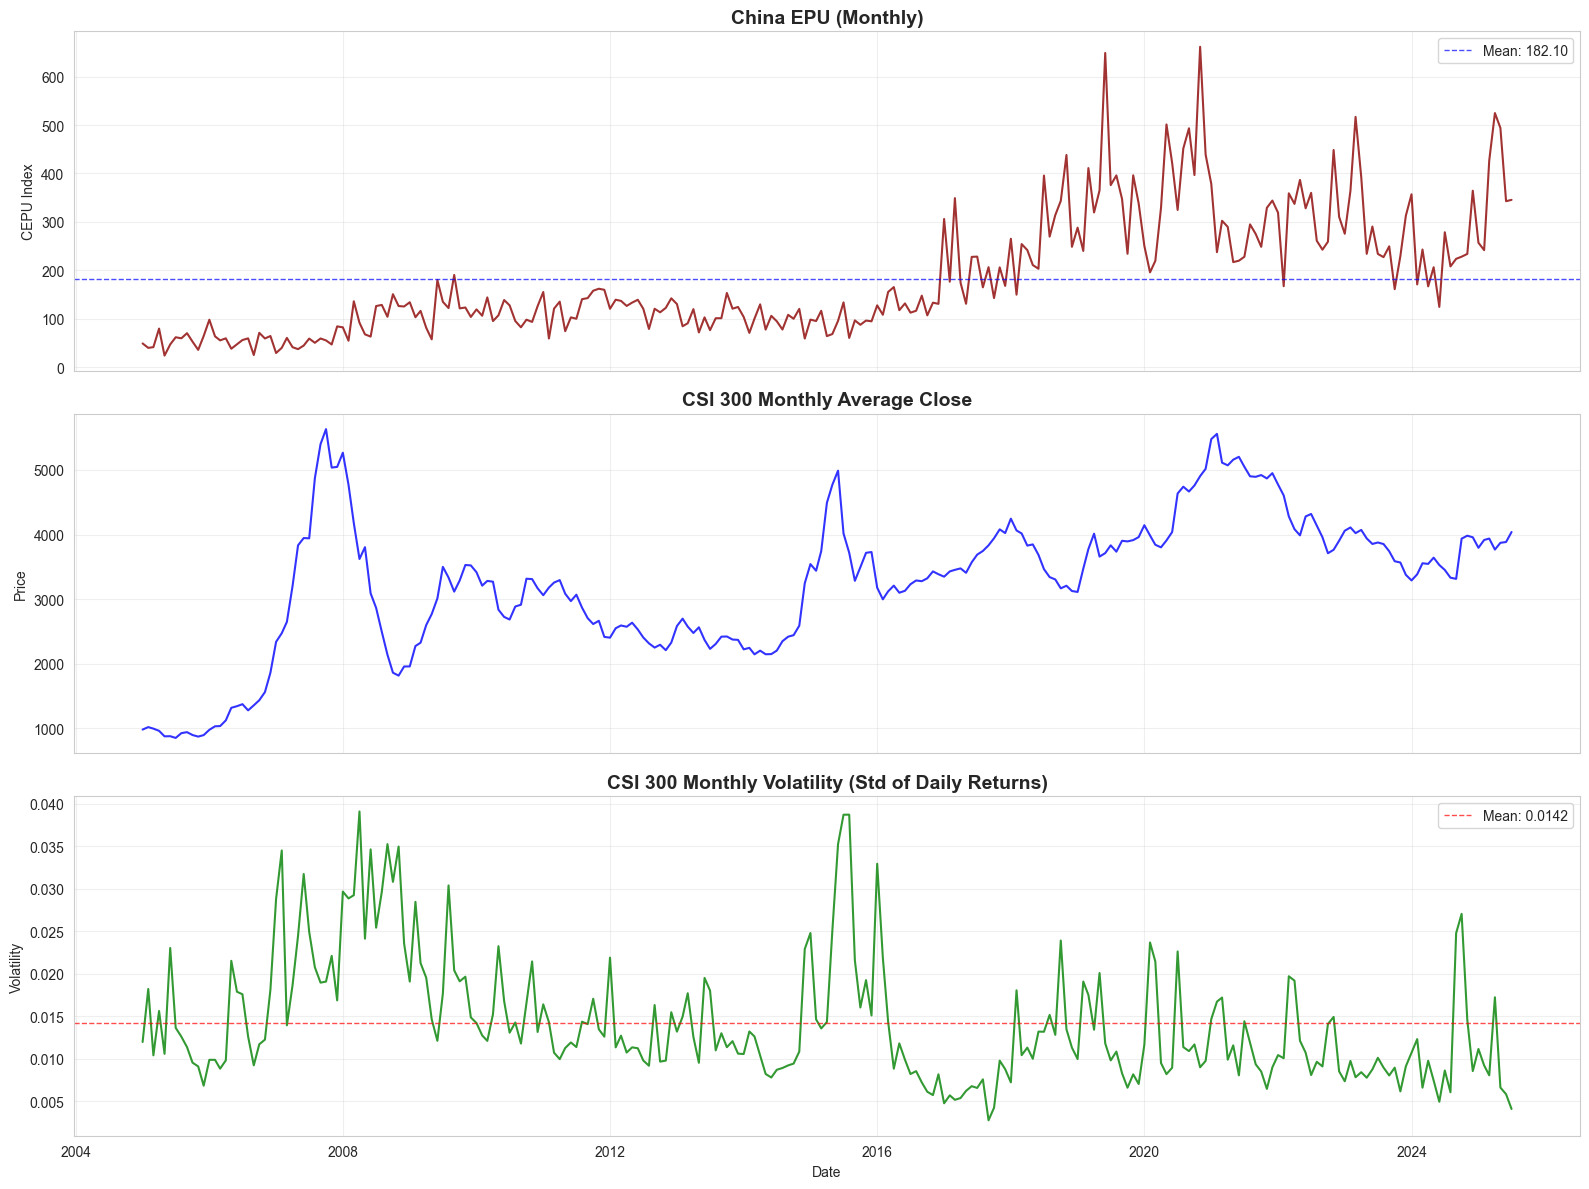

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# CEPU
axes[0].plot(df['Date'], df['CNEPU'], linewidth=1.5, color='darkred', alpha=0.8)
axes[0].axhline(df['CNEPU'].mean(), color='blue', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Mean: {df["CNEPU"].mean():.2f}')
axes[0].set_title('China EPU (Monthly)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('CEPU Index')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CSI 300 (monthly avg close)
axes[1].plot(df['Date'], df['CSI_Close_Avg'], linewidth=1.5, color='blue', alpha=0.8)
axes[1].set_title('CSI 300 Monthly Average Close', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price')
axes[1].grid(True, alpha=0.3)

# CSI 300 Volatility (intra-month daily std)
axes[2].plot(df['Date'], df['CSI_Vol'], linewidth=1.5, color='green', alpha=0.8)
axes[2].axhline(df['CSI_Vol'].mean(), color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Mean: {df["CSI_Vol"].mean():.4f}')
axes[2].set_title('CSI 300 Monthly Volatility (Std of Daily Returns)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Volatility')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

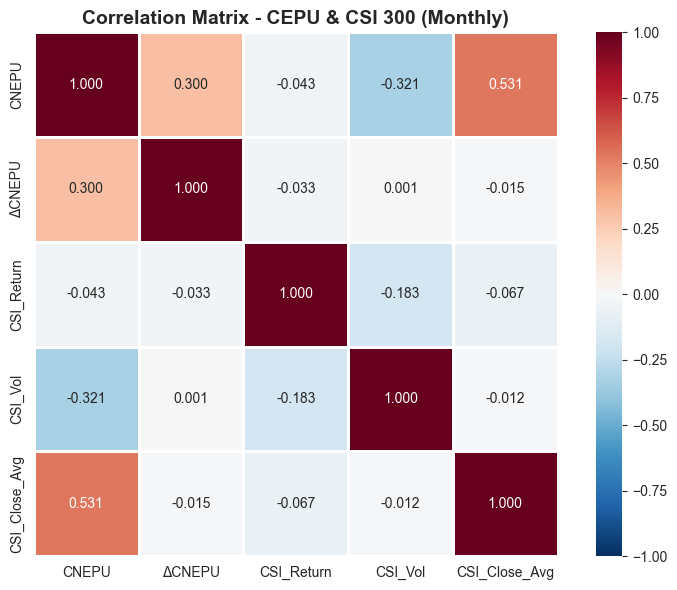

In [51]:
# Correlation heatmap
corr_cols = ['CNEPU', 'ΔCNEPU', 'CSI_Return', 'CSI_Vol', 'CSI_Close_Avg']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - CEPU & CSI 300 (Monthly)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Export

In [52]:
output_path = DATA_PROCESSED / 'cepu_csi300_merged.csv'
df.to_csv(output_path, index=False)

print(f"✓ Exported to: {output_path}")
print(f"  Shape: {df.shape}")
print(f"  Frequency: Monthly")
print(f"  Date range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")
print(f"  Columns: {list(df.columns)}")

# Verify
df_check = pd.read_csv(output_path, parse_dates=['Date'])
print(f"\n✓ Verification: {df_check.shape[0]} rows × {df_check.shape[1]} cols")
display(df_check.head())

✓ Exported to: ../../data/processed/cepu_csi300_merged.csv
  Shape: (247, 17)
  Frequency: Monthly
  Date range: 2005-01 to 2025-07
  Columns: ['Date', 'year', 'month', 'CNEPU', 'ΔCNEPU', 'CNEPU_MA12', 'CNEPU_Std12', 'CSI_Close_Avg', 'CSI_Close_Last', 'CSI_Open_First', 'CSI_High_Max', 'CSI_Low_Min', 'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m', 'CSI_Trading_Days']

✓ Verification: 247 rows × 17 cols


,Date,year,month,CNEPU,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Trading_Days
0,2005-01-01,2005,1,48.805328,NaN,NaN,NaN,982.409000,954.88,994.77,1006.46,943.44,NaN,0.011958,NaN,NaN,20
1,2005-02-01,2005,2,39.653267,-9.152061,NaN,NaN,1020.900000,1039.99,953.33,1059.48,952.74,0.085381,0.018203,NaN,NaN,13
2,2005-03-01,2005,3,41.163791,1.510524,NaN,NaN,996.991739,942.20,1039.35,1054.64,928.34,-0.098749,0.010387,NaN,NaN,23
3,2005-04-01,2005,4,79.471275,38.307484,NaN,NaN,963.126667,932.39,941.43,1008.74,914.83,-0.010466,0.015607,0.092091,NaN,21
4,2005-05-01,2005,5,23.716429,-55.754846,NaN,NaN,877.821765,855.95,934.65,937.39,842.10,-0.085539,0.010562,0.047617,NaN,17


## 9. Summary

In [53]:
print("=" * 70)
print("CHINA ASSETS - CLEANING AND PREPARATION SUMMARY")
print("=" * 70)

print(f"\nInput:")
print(f"  - cepu-china-mainland.csv: Monthly EPU (1949-2025)")
print(f"  - csi300-daily.csv: Daily stock index (2005-2025)")

print(f"\nStrategy:")
print(f"  - CSI 300 daily → aggregated to monthly")
print(f"  - Merged with CEPU on year/month (inner join)")
print(f"  - Both datasets at same monthly frequency")

print(f"\nOutput: data/processed/cepu_csi300_merged.csv")
print(f"  Shape: {df.shape}")
print(f"  Range: {df['Date'].min().strftime('%Y-%m')} to {df['Date'].max().strftime('%Y-%m')}")

print(f"\nFeatures ({len(df.columns)} total):")
print(f"  CEPU:  CNEPU, ΔCNEPU, CNEPU_MA12, CNEPU_Std12")
print(f"  CSI:   CSI_Close_Avg, CSI_Close_Last, CSI_Open_First")
print(f"         CSI_High_Max, CSI_Low_Min")
print(f"  Calc:  CSI_Return (monthly), CSI_Vol (intra-month)")
print(f"         CSI_Vol3m, CSI_Vol6m (rolling)")
print("\n" + "=" * 70)

CHINA ASSETS - CLEANING AND PREPARATION SUMMARY

Input:
  - cepu-china-mainland.csv: Monthly EPU (1949-2025)
  - csi300-daily.csv: Daily stock index (2005-2025)

Strategy:
  - CSI 300 daily → aggregated to monthly
  - Merged with CEPU on year/month (inner join)
  - Both datasets at same monthly frequency

Output: data/processed/cepu_csi300_merged.csv
  Shape: (247, 17)
  Range: 2005-01 to 2025-07

Features (17 total):
  CEPU:  CNEPU, ΔCNEPU, CNEPU_MA12, CNEPU_Std12
  CSI:   CSI_Close_Avg, CSI_Close_Last, CSI_Open_First
         CSI_High_Max, CSI_Low_Min
  Calc:  CSI_Return (monthly), CSI_Vol (intra-month)
         CSI_Vol3m, CSI_Vol6m (rolling)

